In [ ]:
from google.colab import userdata
HF_TOKEN=userdata.get('HF_TOKEN')
HF_TOKEN

In [ ]:
!pip install huggingface_hub

In [ ]:
import huggingface_hub
huggingface_hub.login(token=HF_TOKEN)

In [ ]:
try :
  import datasets,evaluate,accelerate
  import gradio as gr
except :
  !pip install -U datasets evaluate accelerate gradio
  import datasets,evaluate,accelerate
  import gradio as gr
import random
import numpy as np
import torch
import transformers
print("datasets",datasets.__version__)
print("evaluate",evaluate.__version__)
print("accelerate",accelerate.__version__)
print("gradio",gr.__version__)

print("numpy",np.__version__)
print("torch",torch.__version__)
print("transformers",transformers.__version__)

datasets 5.0.0
evaluate 0.4.6
accelerate 1.13.0
gradio 6.17.3
numpy 2.0.2
torch 2.11.0+cu128
transformers 5.9.0


In [ ]:
import random
from datasets import load_dataset

# Load dataset
dataset = load_dataset("mrdbourke/learn_hf_food_not_food_image_captions")


In [ ]:
random_indexes=random.sample(range(len(dataset['train'])),5)
print(random_indexes)
random_samples=dataset['train'][random_indexes]
print(random_samples)
#random
for text,label in zip(random_samples['text'],random_samples['label']):
  print(text,label)

[10, 28, 219, 190, 209]
{'text': ['Set of golf clubs stored in a bag', 'Mouthwatering paneer tikka masala, featuring juicy paneer in a rich tomato-based sauce, garnished with fresh coriander leaves.', 'Two dogs laying on a rug', 'Asparagus in a bowl, sprinkled with Parmesan cheese and served with a side of hollandaise sauce for a classic, flavorful dish.', 'A close-up of a man and his dog sharing a quiet moment on the porch'], 'label': ['not_food', 'food', 'not_food', 'food', 'not_food']}
Set of golf clubs stored in a bag not_food
Mouthwatering paneer tikka masala, featuring juicy paneer in a rich tomato-based sauce, garnished with fresh coriander leaves. food
Two dogs laying on a rug not_food
Asparagus in a bowl, sprinkled with Parmesan cheese and served with a side of hollandaise sauce for a classic, flavorful dish. food
A close-up of a man and his dog sharing a quiet moment on the porch not_food


In [ ]:
for text,label in zip(random_samples['text'],random_samples['label']):
  print(text,label)

Set of golf clubs stored in a bag not_food
Mouthwatering paneer tikka masala, featuring juicy paneer in a rich tomato-based sauce, garnished with fresh coriander leaves. food
Two dogs laying on a rug not_food
Asparagus in a bowl, sprinkled with Parmesan cheese and served with a side of hollandaise sauce for a classic, flavorful dish. food
A close-up of a man and his dog sharing a quiet moment on the porch not_food


In [ ]:
import pandas as pd
food_not_food_df=pd.DataFrame(dataset['train'])
food_not_food_df.head()


,text,label
0,"Creamy cauliflower curry with garlic naan, fea...",food
1,Set of books stacked on a desk,not_food
2,"Watching TV together, a family has their dog s...",not_food
3,Wooden dresser with a mirror reflecting the room,not_food
4,Lawn mower stored in a shed,not_food


In [ ]:
#doing tokenization and spliting the data into test , train split

In [ ]:
#creating a mapping to map our labels to numerical values
id2label={0:"not_food",1:"food"}
label2id={"not_food":0,"food":1}

In [ ]:
#create mapping programmatically


In [ ]:
id2label={idx:label for idx,label in enumerate(dataset['train'].unique("label")[::-1])}
label2id={label:idx for idx,label in id2label.items()}
id2label,label2id
#

({0: 'not_food', 1: 'food'}, {'not_food': 0, 'food': 1})

In [ ]:
id2label={}
for idx,label in enumerate(dataset['train'].unique('label')[::-1]):
  id2label[idx]=label

id2label,label2id

({0: 'not_food', 1: 'food'}, {'not_food': 0, 'food': 1})

In [ ]:
#turn labels into zero 1
def maps_label_to_numbers(example):
  example['label']=label2id[example['label']]
  return example
example_sample=dataset['train'][0]
maps_label_to_numbers(example_sample)

{'text': 'Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
 'label': 1}

In [ ]:
dataset['train'][:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': ['food', 'not_food', 'not_food', 'not_food', 'not_food']}

In [ ]:
dataset=dataset['train'].map(maps_label_to_numbers)


In [ ]:
dataset[:5]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [ ]:
dataset=dataset.train_test_split(test_size=0.2,seed=42)


In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [ ]:
#tokenzing our text data ( tunirng text into numbers)
#tokenizer turn text into numbers , model find patterns in those numbers


In [ ]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained(pretrained_model_name_or_path="distilbert/distilbert-base-uncased",use_fast=True)

In [ ]:
tokenizer("i love myself")

{'input_ids': [101, 1045, 2293, 2870, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

In [ ]:
len(tokenizer.vocab),tokenizer.model_max_length


(30522, 512)

In [ ]:
tokenizer.convert_ids_to_tokens(tokenizer("hellooo").input_ids)

['[CLS]', 'hello', '##oo', '[SEP]']

In [ ]:
list(tokenizer.vocab.items())[:5]

[('legion', 8009),
 ('prc', 26141),
 ('##手', 30384),
 ('steamship', 23869),
 ('hadley', 21681)]

In [ ]:
#making a fucntion to tokenize ourt text

In [ ]:
def tokenize_text(examples):
  return tokenizer(examples['text'],
                   padding=True,
                   truncation=True)

In [ ]:
example_sample={"text":"I love pizza","label":1}
tokenize_text(example_sample)

{'input_ids': [101, 1045, 2293, 10733, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}

In [ ]:
tokenized_dataset=dataset.map(function=tokenize_text,
                              batched=True,
                              batch_size=1000)

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [ ]:
dataset,tokenized_dataset

(DatasetDict({
     train: Dataset({
         features: ['text', 'label'],
         num_rows: 200
     })
     test: Dataset({
         features: ['text', 'label'],
         num_rows: 50
     })
 }),
 DatasetDict({
     train: Dataset({
         features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
         num_rows: 200
     })
     test: Dataset({
         features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
         num_rows: 50
     })
 }))

In [ ]:
tokenizer.all_special_tokens,tokenizer.all_special_ids

(['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]'], [100, 102, 0, 101, 103])

In [ ]:
print(tokenized_dataset['train']['input_ids'][0])
print(tokenized_dataset['train']['text'][0])


[101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Set of headphones placed on a desk


In [ ]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric=evaluate.load('accuracy')

def compute_accuracy(predictions_and_labels:Tuple[np.array,np.array]):
    predictions,labels=predictions_and_labels
    if len(predictions.shape)>=2:
        predictions=np.argmax(predictions,axis=1)
    return accuracy_metric.compute(predictions=predictions,references=labels)

In [ ]:
#create a preprocess data
#define the model we are going to use
#define training arguements
#pass the training models
#save the model
#evaluat our model

In [ ]:
from transformers import AutoModelForSequenceClassification
model=AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path="distilbert-base-uncased",
                                                           num_labels=2,
                                                           id2label=id2label,
                                                           label2id=label2id)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#our model is comprised of following parts
#embedding are form of learned represeatuion of tokens
#trasnformer , this discovers patterns in the embeddinggs
#classifier , we custiomize this layer to suit our problem

In [ ]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def count_params(model):
  trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
  total_params = sum(p.numel() for p in model.parameters())
  return {"trainable_params":trainable_params,"total_params":total_params}
count_params(model)

{'trainable_params': 66955010, 'total_params': 66955010}

In [ ]:
#if you want best possible performance , generally more parameters is better but increase file size

In [ ]:
#create a folder for saving models
from pathlib import Path
models_dir=Path('models')
models_dir.mkdir(exist_ok=True)
model_save_name="learn_hf_food_not_food_text_classifier_distilbert_base_uncased"
model_save_dir=Path(models_dir,model_save_name)

In [ ]:
from transformers import TrainingArguments
BATCH_SIZE=32
print(f"Saving model dir {model_save_dir}")
training_args=TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    num_train_epochs=10,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    use_cpu=False,
    seed=42,
    load_best_model_at_end=True,
    report_to="none",
    logging_strategy="epoch",
    hub_private_repo=False,

)

Saving model dir models/learn_hf_food_not_food_text_classifier_distilbert_base_uncased


In [ ]:
training_args

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval

In [ ]:
from transformers import Trainer
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['test'],
    compute_metrics=compute_accuracy,
)

In [ ]:
results=trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.368433,0.046224,1.000000
2,0.022897,0.005702,1.000000
3,0.004090,0.002092,1.000000
4,0.001809,0.001197,1.000000
5,0.001157,0.000855,1.000000
6,0.000916,0.000696,1.000000
7,0.000731,0.000612,1.000000
8,0.000698,0.000567,1.000000
9,0.000660,0.000543,1.000000
10,0.000602,0.000534,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
for key,value in results.metrics.items():
  print(f"{key}:{value}")

train_runtime:70.1486
train_samples_per_second:28.511
train_steps_per_second:0.998
total_flos:18110777160000.0
train_loss:0.04019923229435725
epoch:10.0


In [ ]:
#save model
trainer.save_model(output_dir=model_save_dir)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
train_history_all=trainer.state.log_history
trainer_history_metric=train_history_all[:-1]
trainer_history_training_time=train_history_all[-1]
trainer_history_metric[:3]

[{'loss': 0.36843293053763254,
  'grad_norm': 1.4051146507263184,
  'learning_rate': 9.142857142857143e-05,
  'epoch': 1.0,
  'step': 7},
 {'eval_loss': 0.04622434079647064,
  'eval_accuracy': 1.0,
  'eval_runtime': 0.0964,
  'eval_samples_per_second': 518.654,
  'eval_steps_per_second': 20.746,
  'epoch': 1.0,
  'step': 7},
 {'loss': 0.022896664483206614,
  'grad_norm': 0.11007378995418549,
  'learning_rate': 8.142857142857143e-05,
  'epoch': 2.0,
  'step': 14}]

In [ ]:
import pprint
trainer_history_training_set=[]
trainer_history_eval_set=[]
for item in trainer_history_metric:
  item_keys=list(item.keys())
  if any("eval" in key for key in item_keys):
    trainer_history_eval_set.append(item)
  else:
    trainer_history_training_set.append(item)

trainer_history_eval_set[:3],trainer_history_training_set[:3]

([{'eval_loss': 0.04622434079647064,
   'eval_accuracy': 1.0,
   'eval_runtime': 0.0964,
   'eval_samples_per_second': 518.654,
   'eval_steps_per_second': 20.746,
   'epoch': 1.0,
   'step': 7},
  {'eval_loss': 0.0057020168751478195,
   'eval_accuracy': 1.0,
   'eval_runtime': 0.1404,
   'eval_samples_per_second': 356.095,
   'eval_steps_per_second': 14.244,
   'epoch': 2.0,
   'step': 14},
  {'eval_loss': 0.0020920380484312773,
   'eval_accuracy': 1.0,
   'eval_runtime': 0.0728,
   'eval_samples_per_second': 686.888,
   'eval_steps_per_second': 27.476,
   'epoch': 3.0,
   'step': 21}],
 [{'loss': 0.36843293053763254,
   'grad_norm': 1.4051146507263184,
   'learning_rate': 9.142857142857143e-05,
   'epoch': 1.0,
   'step': 7},
  {'loss': 0.022896664483206614,
   'grad_norm': 0.11007378995418549,
   'learning_rate': 8.142857142857143e-05,
   'epoch': 2.0,
   'step': 14},
  {'loss': 0.004090344001139913,
   'grad_norm': 0.04460838437080383,
   'learning_rate': 7.142857142857143e-05,
   

In [ ]:
trainer_history_train_df=pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df=pd.DataFrame(trainer_history_eval_set)
trainer_history_train_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.368433,1.405115,0.000091,1.0,7
1,0.022897,0.110074,0.000081,2.0,14
2,0.004090,0.044608,0.000071,3.0,21
3,0.001809,0.025139,0.000061,4.0,28
4,0.001157,0.016922,0.000051,5.0,35


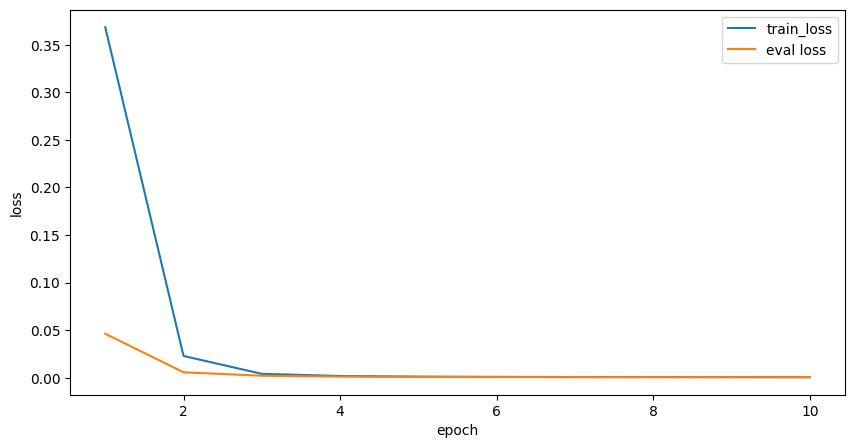

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(trainer_history_train_df['epoch'],trainer_history_train_df['loss'],label='train_loss')
plt.plot(trainer_history_eval_df['epoch'],trainer_history_eval_df['eval_loss'],label='eval loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
# model_upload_url=trainer.push_to_hub(
#     commit_message="uploading food not food text classifier model v1.2",
#     token=HF_TOKEN
# )

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...uncased/model.safetensors:   2%|1         | 4.04MB /  268MB            

  ...uncased/training_args.bin:   1%|          |  48.0B / 5.33kB            

In [ ]:
#perform predicitons on the test data
predictions_all=trainer.predict(tokenized_dataset['test'])

In [ ]:
predictions_all

PredictionOutput(predictions=array([[-4.0035644,  3.4121811],
       [ 4.0286403, -3.7706919],
       [-3.995956 ,  3.420849 ],
       [ 4.0635247, -3.805618 ],
       [ 4.061863 , -3.7902806],
       [-4.006033 ,  3.4144223],
       [ 4.054553 , -3.793626 ],
       [ 4.0546956, -3.7940776],
       [-4.0036993,  3.4126751],
       [-4.000474 ,  3.408966 ],
       [-4.001749 ,  3.4118512],
       [-3.985666 ,  3.4043262],
       [ 4.0405893, -3.7818348],
       [-3.9969058,  3.41706  ],
       [-3.995159 ,  3.3986065],
       [ 4.0564127, -3.8060596],
       [-4.003657 ,  3.4142332],
       [ 4.0082126, -3.7174242],
       [-3.9959366,  3.4171553],
       [-4.006052 ,  3.4089305],
       [-3.9848135,  3.430342 ],
       [-4.0073957,  3.4088182],
       [ 4.0516024, -3.7981913],
       [ 4.0647507, -3.7858145],
       [-3.9934335,  3.4197605],
       [-3.9969187,  3.4139445],
       [-3.984995 ,  3.412737 ],
       [ 4.053334 , -3.776808 ],
       [-3.9996097,  3.416888 ],
       [ 4.042

In [ ]:
#pytorch uses logit s so we have convert it into pred prob

In [ ]:
#lets get predicted probablities
import torch
from sklearn.metrics import accuracy_score
pred_probs=torch.softmax(torch.tensor(predictions_all[0]),dim=1)
pred_labels=torch.argmax(pred_probs,dim=1)
pred_labels

tensor([1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0,
        1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1,
        0, 1])

In [ ]:
true_labels=tokenized_dataset["test"]['label']
test_accuracy=accuracy_score(y_true=true_labels,
                y_pred=pred_labels)

In [ ]:
test_accuracy

1.0

In [ ]:
test_predictions_df=pd.DataFrame({
    "text":tokenized_dataset['test']['text'],
    "true_labels":true_labels,
    "pred_labels":pred_labels,
    "pred_probs":torch.max(pred_probs,dim=1).values

})
test_predictions_df.head()



,text,true_labels,pred_labels,pred_probs
0,A slice of pepperoni pizza with a layer of mel...,1,1,0.999399
1,Red brick fireplace with a mantel serving as a...,0,0,0.999590
2,A bowl of sliced bell peppers with a sprinkle ...,1,1,0.999399
3,Set of mugs hanging on a hook,0,0,0.999618
4,Standing floor lamp providing light next to an...,0,0,0.999611


In [ ]:
local_model_path="/content/models/learn_hf_food_not_food_text_classifier_distilbert_base_uncased/"
huggin_face_model_path="Aun3223/learn_hf_food_not_food_text_classifier_distilbert_base_uncased"

In [ ]:
import torch
def set_device():
  if torch.cuda.is_available():
      device=torch.device("cuda")
  elif torch.backends.mps.is_available() and torch.backends.mpsiis_built():
      device=torch.device("mps")
  else:
      device=torch.device("cpu")
  return device

DEVICE=set_device()
print("Using dvice",DEVICE)

Using dvice cuda


In [ ]:
# 1. Explicitly inject the mappings into your model configuration
from transformers import pipeline
from transformers import AutoTokenizer

model.config.id2label = {0: "not_food", 1: "food"}
model.config.label2id = {"not_food": 0, "food": 1}

# 2. Re-instantiate your classifier pipeline using the updated model architecture
food_not_food_classifier = pipeline(
    task="text-classification",
    model=local_model_path,
 tokenizer=tokenizer,
  top_k=1,

    device=0 ,# Ensures it matches your CUDA runtimeh
    batch_size=32
)



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [ ]:
# 3. Re-run your manual sentence text check
test_custom_sentence = "a burger"
print(food_not_food_classifier(test_custom_sentence))

[[{'label': 'food', 'score': 0.9682505130767822}]]


In [ ]:
# from transformers import AutoTokenizer,AutoModelForSequenceClassification
# pretrained_model_name_or_path="Aun3223/learn_hf_food_not_food_text_classifier_distilbert_base_uncased"
# tokenizer=AutoTokenizer.from_pretrained(pretrained_model_name_or_path=huggin_face_model_path)
# model=AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path=huggin_face_model_path)

# inputs=tokenizer(test_custom_sentence,
#                  return_tensors="pt")

# inputs

In [ ]:
# import torch
# model.eval()
# with torch.inference_mode():
#   outputs=model(**inputs)
#   outputs_verbose=model(input_ids=inputs["input_ids"],
#                 attention_mask=inputs["attention_mask"])
# outputs

In [ ]:
# predicted_class_id=outputs.logits.argmax().item()
# predicted_class_id
# prediction_probablity=outputs.logits.softmax(dim=1)[0].max().item()
# print(f"predicted class id:{predicted_class_id}")
# print(f"prediction probablity:{prediction_probablity}")
# print(f"predicted class label:{model.config.id2label[predicted_class_id]}")

In [ ]:
#the demo

In [ ]:
from typing import Dict
from transformers import pipeline

# 1. Update your in-memory model config safely
model.config.id2label = {0: "not_food", 1: "food"}
model.config.label2id = {"not_food": 0, "food": 1}

# 2. Instantiate the pipeline ONCE outside the function using the model instance
food_not_food_classifier_pipeline = pipeline(
    task="text-classification",
    model=model,        # <--- Pass the live 'model' object, NOT local_model_path
    tokenizer=tokenizer,
    device=0,
    top_k=None,# Matches your GPU runtime
    batch_size=32
)

# 3. Keep the function lightweight just for parsing text
def food_not_food_classifier_func(text: str) -> Dict[str, float]:
    # Because top_k=1 is set, the pipeline returns a list containing one dictionary: [{'label': '...', 'score': ...}]
    outputs = food_not_food_classifier_pipeline(text)[0]

    output_dict = {}
    for item in outputs:
        output_dict[item['label']] = item['score']
    return output_dict

# Test inputs

print(food_not_food_classifier_func("a cheese slice"))

{'food': 0.999342143535614, 'not_food': 0.0006578940665349364}


In [ ]:
import gradio as gr
demo=gr.Interface(
    fn=food_not_food_classifier_func,
    inputs="text",
    outputs=gr.Label(num_top_classes=2),
    title="Food Not Food Classifier",
    description="Classify if text is food or not food"

)
demo.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8e92edf4820a2b11d3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset1.csv
